#VERSION FINALE

#Ce script construit un modèle pour:
# a/Classifier les erreurs médicamenteuses en "graves" ou "non graves"en se basant sur les commentaires des pharmaciens.
# b/Classifier automatiquement les commentaires des pharmaciens en 11 classes principales de problèmes médicamenteux.

#1.Importation des bibliothèques et configuration initiale

In [58]:
# ===================================================
# 1. IMPORTATIONS ET CONFIGURATION
# ===================================================

import pandas as pd # Pour la manipulation des données tabulaires
import numpy as np # Pour les opérations numériques (arrays, etc.)
import re # Pour les expressions régulières (nettoyage de texte)
import unicodedata # Pour normaliser les caractères Unicode (accents, etc.)
import nltk # Bibliothèque pour le traitement du langage naturel
from nltk.stem.snowball import SnowballStemmer # Pour la racisation des mots (stemming)

# Importations pour la modélisation et l'évaluation
from sklearn.feature_extraction.text import TfidfVectorizer # Pour vectoriser le texte (TF-IDF)
from sklearn.preprocessing import OneHotEncoder # Pour encoder les variables catégorielles (One-Hot)
from sklearn.compose import ColumnTransformer # Pour appliquer différents transformateurs à différentes colonnes
from sklearn.pipeline import Pipeline # Pour créer des pipelines de prétraitement et de modélisation

# Importations pour la division des données, les modèles et l'optimisation
from sklearn.model_selection import train_test_split, GridSearchCV # Pour diviser les données et optimiser les hyperparamètres
from sklearn.linear_model import LogisticRegression # Modèle de régression logistique
from sklearn.ensemble import RandomForestClassifier, VotingClassifier # Modèles de forêt aléatoire et de vote
from xgboost import XGBClassifier # Modèle XGBoost (boosting)

# Importations pour l'évaluation des performances et la gestion du déséquilibre
from sklearn.metrics import f1_score, classification_report, confusion_matrix, precision_recall_curve # Métriques d'évaluation
from imblearn.over_sampling import SMOTE # Pour la technique de suréchantillonnage SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline compatible avec imblearn

# Importations pour la visualisation
import matplotlib.pyplot as plt # Pour la création de graphiques
import seaborn as sns # Pour des visualisations statistiques améliorées

# Téléchargement des stopwords de NLTK :
# Tente de trouver les stopwords, si elles ne sont pas trouvées (LookupError), les télécharge.
try:
    nltk.data.find('corpora/stopwords')
except LookupError: # Correction: seulement LookupError est nécessaire ici
    nltk.download('stopwords')

# Définition de la graine pour la reproductibilité:
SEED = 42
np.random.seed(SEED)

print("--- Bibliothèques importées et configuration terminée ---")

--- Bibliothèques importées et configuration terminée ---


#Palette de Couleurs

In [59]:
# Définition d'une palette de couleurs féminines pour les graphiques
colors_feminine = ['#FFB6C1', '#DB7093', '#C71585', '#BA55D3', '#9370DB', '#8A2BE2', '#4682B4']
sns.set_palette(sns.color_palette(colors_feminine))

print("Palette de couleurs définie.")

Palette de couleurs définie.


#2 : Fonctions de nettoyage et chargement des données

La fonction clean_text qui sera utilisée pour prétraiter les commentaires des pharmaciens. Ensuite, nous chargeons le jeu de données depuis le fichier CSV et effectuons une première vérification des colonnes requises.



In [60]:
# ===================================================
# 2. FONCTIONS DE NETTOYAGE ET CHARGEMENT DES DONNÉES
# ===================================================

def clean_text(text):
    """
    Fonction pour nettoyer et prétraiter le texte des avis :
    - Convertit le texte en minuscules.
    - Supprime les accents et les caractères spéciaux.
    - Remplace les dates et dosages spécifiques par des tokens génériques (' date ', ' dosage ').
    - Supprime les caractères qui ne sont pas des lettres ou des espaces.
    - Remplace les espaces multiples par un seul espace et supprime les espaces en début/fin.
    - Applique la racisation (stemming) aux mots.
    """
    text = str(text).lower() # Convertit en minuscules
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8') # Supprime les accents
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}', ' date ', text) # Remplacement par token générique pour les dates
    text = re.sub(r'\d+(?:[\.,]\d+)?\s*(?:mg|ml|cp|g|kg)', ' dosage ', text) # Remplacement des dosages par un token
    text = re.sub(r'[^a-z\s]', ' ', text) # Supprime les caractères qui ne sont pas des lettres minuscules ou des espaces
    text = re.sub(r'\s+', ' ', text).strip() # Remplace les espaces multiples et supprime les espaces en début/fin

    # Stemming (réduction des mots à leur racine)
    stemmer = SnowballStemmer('french')
    tokens = text.split()
    stemmed_tokens = [stemmer.stem(word) for word in tokens if len(word) > 2] # Ignore les mots très courts après racisation
    return ' '.join(stemmed_tokens)

# Chargement du jeu de données
print("Chargement des données...")
# On lit le fichier en spécifiant le séparateur ";"
try:
    data = pd.read_csv('/content/data_defi3.csv', sep=';')
    print("Données chargées avec succès.")
except FileNotFoundError:
    print("Erreur : Le fichier 'data_defi3.csv' est introuvable. Assurez-vous qu'il est dans le bon répertoire.")
    # Crée un DataFrame vide pour éviter les erreurs dans les cellules suivantes
    data = pd.DataFrame(columns=['Avis.Pharmaceutique', 'PLT', 'Libellé.Prescription'])


# Vérification et nettoyage initial des colonnes essentielles
required_columns = ['Avis.Pharmaceutique', 'PLT', 'Libellé.Prescription']
if all(col in data.columns for col in required_columns):
    # Supprime les lignes où les colonnes requises ont des valeurs manquantes
    data = data.dropna(subset=required_columns)
    # Convertit la colonne 'PLT' en numérique, remplace les erreurs par 0 et convertit en entier
    data['PLT'] = pd.to_numeric(data['PLT'], errors='coerce').fillna(0).astype(int)
else:
    print("Erreur: Une ou plusieurs colonnes requises sont manquantes.")

Chargement des données...
Données chargées avec succès.


#Graphique 1 : Distribution des 11 Classes Principales
Objectif : Comprendre la répartition des problèmes. Cela mettra immédiatement en évidence le fort déséquilibre : certaines classes sont très fréquentes, d'autres extrêmement rares.

/tmp/ipython-input-1500769870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_multi, order=y_multi.value_counts().index, palette=colors_feminine)
/tmp/ipython-input-1500769870.py:5: UserWarning: 
The palette list has fewer values (7) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=y_multi, order=y_multi.value_counts().index, palette=colors_feminine)


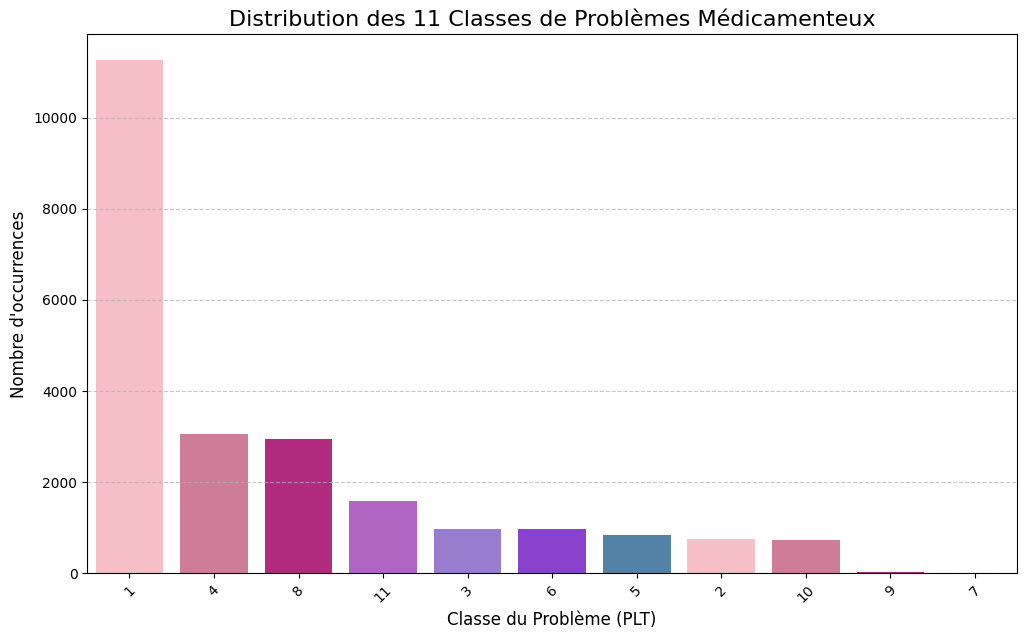

In [61]:
# ===================================================
# GRAPHIQUE 1 : DISTRIBUTION DES CLASSES MULTICLASSES
# ===================================================
plt.figure(figsize=(12, 7))
sns.countplot(x=y_multi, order=y_multi.value_counts().index, palette=colors_feminine)
plt.title('Distribution des 11 Classes de Problèmes Médicamenteux', fontsize=16)
plt.xlabel('Classe du Problème (PLT)', fontsize=12)
plt.ylabel('Nombre d\'occurrences', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3 : Préparation des données et création des cibles

 La fonction de nettoyage, crée les nouvelles colonnes (Avis_Cleaned, Molecule_Cleaned), et définit les variables cibles (y_binary, y_multi) ainsi que les caractéristiques (X).


*Modifier la Préparation des Données (pour ajouter le Feature Engineering)
Cette modification se fait juste après le chargement des données et avant la division Train/Test. C'est ici que vous allez créer vos nouvelles colonnes de mots-clés.

In [62]:
# ===================================================
# 3. PRÉPARATION AMÉLIORÉE DES DONNÉES (AVEC FEATURE ENGINEERING)
# ===================================================
print("Nettoyage et préparation des données...")

# --- Nettoyage du texte (inchangé) ---
data['Avis_Cleaned'] = data['Avis.Pharmaceutique'].apply(clean_text)
data['Molecule_Cleaned'] = data['Libellé.Prescription'].astype(str).str.lower().str.strip()

# --- NOUVEAUTÉ : Ajout des caractéristiques basées sur des mots-clés ---
# On applique ces règles sur le texte original, avant nettoyage complet
avis_brut = data['Avis.Pharmaceutique'].str.lower()
data['contient_ci'] = avis_brut.str.contains('contre-indiqu|contre indication|CI', regex=True).astype(int)
data['contient_surdosage'] = avis_brut.str.contains('surdosage|diminuer la dose|réduire la posologie|dose trop|posologie élevée', regex=True).astype(int)
data['contient_interaction'] = avis_brut.str.contains('interaction|association déconseillée', regex=True).astype(int)
print("Nouvelles caractéristiques (mots-clés) créées.")

# Définition des cibles (inchangé)
y_binary = data['PLT'].isin([4, 5, 6.3, 6.4]).astype(int)
y_multi = data['PLT']

# --- MISE À JOUR : Définition des features (X) ---
# On inclut maintenant les nouvelles colonnes
X = data[['Avis_Cleaned', 'Molecule_Cleaned', 'contient_ci', 'contient_surdosage', 'contient_interaction']]

print("Préparation des données terminée.")
X.head()

Nettoyage et préparation des données...
Nouvelles caractéristiques (mots-clés) créées.
Préparation des données terminée.


,Avis_Cleaned,Molecule_Cleaned,contient_ci,contient_surdosage,contient_interaction
0,dat pas indiqu,"contramal 100 mg/ml, gouttes buv (tramadol)",0,0,0
1,dat recommand imovan dosag couch,"imovane 7.5 mg, cpr sécable (zopiclone)",0,0,0
2,vu dfg est recommand administr dosag donne gpr...,"colchicine 1 mg, cpr sécable (colchicine)",0,0,0
3,dos curat absenc atcd gastriqu retrouv recomma...,"pantoprazole 40 mg, cpr gastro-résistant (eupa...",0,1,0
4,posolog infrat veuill reevalu posolog nous pro...,vancomycine 500 mg 1x/j,0,0,0


#Graphique 2 : Déséquilibre entre Cas Graves et Non Graves
Objectif : Visualiser à quel point la classe "Grave" est minoritaire. Une tarte est très efficace pour montrer cette proportion.

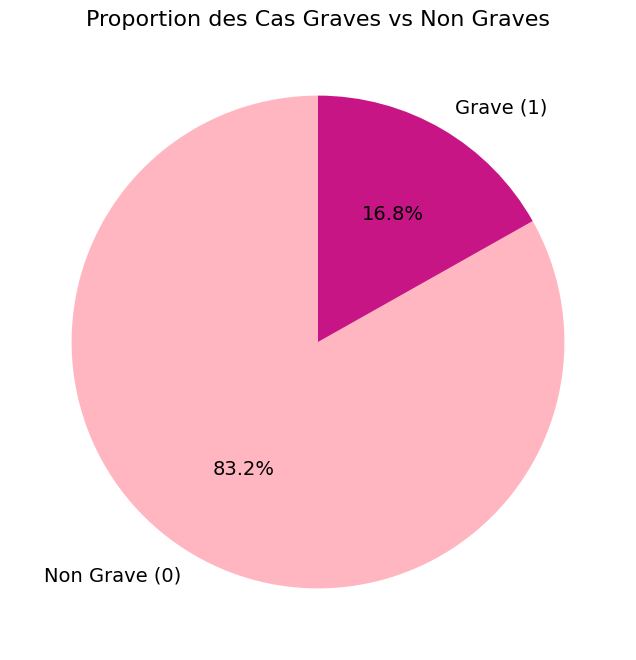

In [63]:
# ===================================================
# GRAPHIQUE 2 : PROPORTION DES CAS GRAVES VS NON GRAVES
# ===================================================
plt.figure(figsize=(8, 8))
y_binary.value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#FFB6C1', '#C71585'],
    labels=['Non Grave (0)', 'Grave (1)'],
    startangle=90,
    textprops={'fontsize': 14}
)
plt.title('Proportion des Cas Graves vs Non Graves', fontsize=16)
plt.ylabel('') # Pour enlever le label "None" sur le côté
plt.show()

#4 : Division des données en ensembles d'entraînement et de test

Nous séparons ici nos données en un ensemble d'entraînement (pour former les modèles) et un ensemble de test (pour les évaluer). La stratification (stratify=y_multi) est utilisée pour s'assurer que la proportion des différentes classes est la même dans les deux ensembles.

In [64]:
# ===================================================
# 4. DIVISION TRAIN/TEST
# ===================================================
print("Division des données en ensembles d'entraînement et de test...")

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multi,
    test_size=0.2,
    random_state=SEED,
    stratify=y_multi # Stratification pour conserver la distribution des classes
)

print(f"Taille de l'ensemble d'entraînement : {len(X_train)} échantillons")
print(f"Taille de l'ensemble de test : {len(X_test)} échantillons")

Division des données en ensembles d'entraînement et de test...
Taille de l'ensemble d'entraînement : 18512 échantillons
Taille de l'ensemble de test : 4629 échantillons


#5 : Création du pipeline de prétraitement

Nous définissons un ColumnTransformer qui appliquera des transformations différentes aux colonnes :
TfidfVectorizer pour la colonne de texte Avis_Cleaned.
OneHotEncoder pour la colonne catégorielle Molecule_Cleaned.
Ce préprocesseur sera la première étape de nos pipelines de modélisation.

In [65]:
# ===================================================
# 5. CRÉATION DU PRÉPROCESSEUR DE FEATURES
# ===================================================

# Liste de mots vides français, enrichie avec des termes spécifiques au domaine( Stopwords)
french_stopwords = nltk.corpus.stopwords.words('french') + \
                  ['patient', 'traitement', 'prescription', 'jour', 'matin', 'soir']
# --- MISE À JOUR : Définition du ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        # Transformation du texte (inchangé)
        ('txt', TfidfVectorizer(stop_words=french_stopwords, ngram_range=(1, 3),
                                max_features=5000, min_df=3, sublinear_tf=True), 'Avis_Cleaned'),

        # Transformation de la molécule (inchangé)
        ('mol', OneHotEncoder(handle_unknown='ignore', sparse_output=True), ['Molecule_Cleaned'])
    ],
    # NOUVEAUTÉ : On garde les autres colonnes (nos nouvelles features de mots-clés)
    remainder='passthrough'
) # <-- Added the closing parenthesis here

print("Préprocesseur créé avec succès.")

Préprocesseur créé avec succès.


#6 : Tâche 1 (Binaire) - Définition du modèle d'ensemble

Nous configurons ici les modèles pour la classification binaire. Un VotingClassifier est créé pour combiner les forces de trois modèles : LogisticRegression, RandomForestClassifier et XGBClassifier. Le vote "soft" permet de moyenner leurs probabilités, ce qui est utile pour l'optimisation du seuil.

In [66]:
# ===================================================
# 6. TÂCHE 1 (BINAIRE) : DÉFINITION DU MODÈLE
# ===================================================
print("--- TÂCHE 1 : CLASSIFICATION BINAIRE (Grave/Non Grave) ---")

# Modèle 1 : Régression Logistique
clf1 = LogisticRegression(max_iter=2000, solver='liblinear', C=1.0, random_state=SEED)

# Modèle 2 : Forêt Aléatoire
clf2 = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1)

# Modèle 3 : XGBoost avec gestion du déséquilibre
ratio = float(np.sum(y_train_bin == 0)) / np.sum(y_train_bin == 1)
clf3 = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                     scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss', random_state=SEED, n_jobs=-1)

# Combinaison des modèles avec un Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('xgb', clf3)],
    voting='soft' # Vote basé sur les probabilités
)

print("Modèle d'ensemble (VotingClassifier) défini.")

--- TÂCHE 1 : CLASSIFICATION BINAIRE (Grave/Non Grave) ---
Modèle d'ensemble (VotingClassifier) défini.


#VISUALISATION DE MODELE

In [67]:
from IPython.display import display, HTML

# 1. Stockez tout votre code HTML dans une variable string multi-lignes
html_diagram = """
### Architecture du Modèle d'Ensemble pour la Classification Binaire

Le code ci-dessus définit une approche d'**ensembling** appelée **Voting Classifier**. L'objectif est de combiner les forces de trois modèles de classification différents et complémentaires pour obtenir une prédiction plus robuste et performante.

Le principe est le suivant : chaque modèle analyse les données et donne son "vote" (sous forme de probabilité). Le `VotingClassifier` agrège ensuite ces votes pour prendre une décision finale.

<div style="font-family: Arial, sans-serif; text-align: center; border: 2px solid #DB7093; border-radius: 10px; padding: 20px; background-color: #FFF0F5;">
    <h4 style="color: #C71585;">Données d'Entrée (Avis + Molécule)</h4>
    <p style="font-size: 24px; margin: 0; color: #DB7093;">⬇</p>

    <div style="display: flex; justify-content: space-around; align-items: flex-start; margin-top: 10px;">
        <!-- Modèle 1 -->
        <div style="width: 30%; border: 1px dashed #BA55D3; border-radius: 8px; padding: 10px; background-color: #FFFFFF;">
            <strong style="color: #9370DB;">Modèle 1</strong><br>
            Régression Logistique
            <p style="font-size: 12px; color: #888;">Bon pour les relations linéaires.</p>
        </div>

        <!-- Modèle 2 -->
        <div style="width: 30%; border: 1px dashed #BA55D3; border-radius: 8px; padding: 10px; background-color: #FFFFFF;">
            <strong style="color: #9370DB;">Modèle 2</strong><br>
            Random Forest
            <p style="font-size: 12px; color: #888;">Robuste et gère bien les interactions complexes.</p>
        </div>

        <!-- Modèle 3 -->
        <div style="width: 30%; border: 1px dashed #BA55D3; border-radius: 8px; padding: 10px; background-color: #FFFFFF;">
            <strong style="color: #9370DB;">Modèle 3</strong><br>
            XGBoost
            <p style="font-size: 12px; color: #888;">Très performant, surtout sur les données structurées.</p>
        </div>
    </div>

    <p style="font-size: 24px; margin: 10px 0; color: #DB7093;">⬇</p>

    <div style="border: 2px solid #C71585; border-radius: 8px; padding: 15px; background-color: #FFE4E1;">
        <h4 style="margin: 0; color: #C71585;">Voting Classifier (vote "soft")</h4>
        <p style="font-size: 14px; margin: 5px 0 0 0;">Moyenne des probabilités prédites par chaque modèle.</p>
    </div>

    <p style="font-size: 24px; margin: 10px 0; color: #DB7093;">⬇</p>

    <h4 style="color: #C71585;">Probabilité Finale ("Grave" / "Non Grave")</h4>
</div>
"""

# 2. Utilisez display(HTML(...)) pour afficher le diagramme
display(HTML(html_diagram))

#7 : Tâche 1 (Binaire) - Pipeline complet et entraînement

Nous assemblons le pipeline final pour la tâche binaire. Il enchaîne le preprocessor, la technique de sur-échantillonnage SMOTE (pour gérer le déséquilibre des classes), et notre VotingClassifier. Le modèle est ensuite entraîné sur les données d'entraînement.

In [68]:
# ===================================================
# 7. TÂCHE 1 (BINAIRE) : PIPELINE COMPLET ET ENTRAÎNEMENT
# ===================================================

# Création du pipeline complet avec SMOTE
binary_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('classifier', voting_clf)
])

print("Entraînement du modèle binaire (cela peut prendre quelques instants)...")
binary_pipeline.fit(X_train, y_train_bin)
print("Entraînement terminé.")

Entraînement du modèle binaire (cela peut prendre quelques instants)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:42:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entraînement terminé.


#8 : Tâche 1 (Binaire) - Optimisation du seuil et évaluation


#  Modifier l'Optimisation du Seuil (pour maximiser le Rappel)
 Au lieu de chercher le F1-score maximum, nous allons chercher le meilleur Rappel (Recall) possible, tout en nous assurant que la Précision ne tombe pas trop bas (par exemple, pas en dessous de 70%).
Reprenons notre Cellule 8 (Optimisation du seuil) et modifiez la logique de recherche du meilleur seuil :

In [106]:
# ===================================================
# 8. TÂCHE 1 (BINAIRE) : COMPARAISON DES STRATÉGIES DE SEUIL (VERSION CORRIGÉE)
# ===================================================

def evaluate_threshold(name, y_true, y_probas, threshold):
    """
    Fonction pour évaluer et afficher les résultats pour un seuil donné.
    MAINTENANT, elle RETOURNE aussi la matrice de confusion.
    """
    print(f"\n--- Résultats pour la stratégie : '{name}' (Seuil = {threshold:.4f}) ---")
    y_pred = (y_probas >= threshold).astype(int)
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print(f"Matrice de confusion :\n{cm}")
    print(f"Cas graves manqués (FN) : {cm[1, 0]} sur {cm[1, 0] + cm[1, 1]}")

    # CORRECTION 1 : On retourne la matrice pour pouvoir la sauvegarder
    return cm

# 1. Calculs initiaux (inchangé)
print("Calcul des probabilités et des courbes Précision-Rappel...")
y_probas = binary_pipeline.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, y_probas)

# --- Stratégie 1 : Optimisation F1-Score ---
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx_f1 = np.nanargmax(f1_scores)
best_threshold_f1 = thresholds[best_idx_f1]
# CORRECTION 2 : On sauvegarde le résultat de la fonction dans la variable 'cm_f1'
cm_f1 = evaluate_threshold("F1-Score Optimal", y_test_bin, y_probas, best_threshold_f1)

# --- Stratégie 2 : Optimisation Rappel ---
min_precision = 0.70
valid_indices = np.where(precisions[:-1] >= min_precision)[0]

if len(valid_indices) > 0:
    best_idx_recall = valid_indices[np.argmax(recalls[valid_indices])]
    best_threshold_recall = thresholds[best_idx_recall]
    # CORRECTION 3 : On sauvegarde le résultat de la fonction dans la variable 'cm_recall'
    cm_recall = evaluate_threshold(f"Rappel Optimal (Précision >= {min_precision:.0%})", y_test_bin, y_probas, best_threshold_recall)
else:
    print(f"\nAVERTISSEMENT : Aucun seuil ne permet d'atteindre une Précision d'au moins {min_precision:.0%}.")
    best_threshold_recall = best_threshold_f1
    # CORRECTION 4 : Si la stratégie 2 échoue, on s'assure que 'cm_recall' existe quand même
    cm_recall = cm_f1

# --- Décision finale (inchangé) ---
print("\n" + "="*50)
print("DÉCISION FINALE : Le seuil optimisé pour le Rappel est choisi pour la suite du projet.")
final_threshold = best_threshold_recall
y_pred_bin_opt = (y_probas >= final_threshold).astype(int)
print(f"Seuil final retenu : {final_threshold:.4f}")
print("="*50)

Calcul des probabilités et des courbes Précision-Rappel...

--- Résultats pour la stratégie : 'F1-Score Optimal' (Seuil = 0.6539) ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3850
           1       0.85      0.76      0.80       779

    accuracy                           0.94      4629
   macro avg       0.90      0.87      0.88      4629
weighted avg       0.93      0.94      0.94      4629

Matrice de confusion :
[[3744  106]
 [ 187  592]]
Cas graves manqués (FN) : 187 sur 779

--- Résultats pour la stratégie : 'Rappel Optimal (Précision >= 70%)' (Seuil = 0.4728) ---
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      3850
           1       0.70      0.87      0.78       779

    accuracy                           0.92      4629
   macro avg       0.84      0.90      0.86      4629
weighted avg       0.93      0.92      0.92      4629

Matrice de confusion :
[[3560  2

#Distribution des Probabilités Prédites

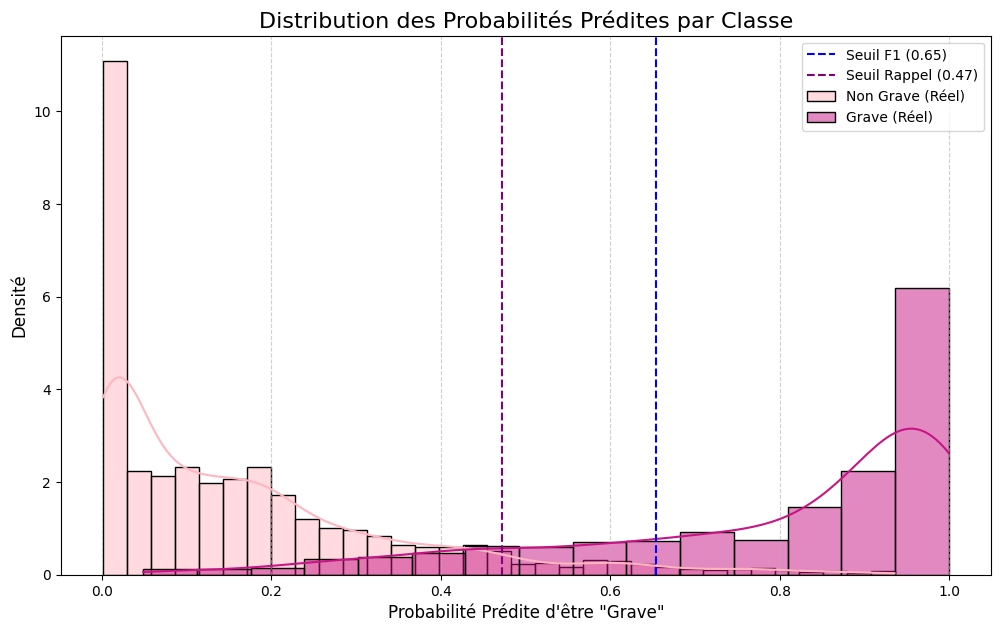

In [108]:
#  Graphique 1 : Distribution des Probabilités Prédites ---
# Objectif : Montrer comment le modèle "note" les cas. On voit si les classes sont bien séparées
# et où nos seuils se positionnent par rapport à ces notes.
plt.figure(figsize=(12, 7))
sns.histplot(x=y_probas[y_test_bin == 0], color='#FFB6C1', label='Non Grave (Réel)', stat='density', kde=True)
sns.histplot(x=y_probas[y_test_bin == 1], color='#C71585', label='Grave (Réel)', stat='density', kde=True)

# Ajouter des lignes verticales pour nos deux seuils choisis
plt.axvline(best_threshold_f1, color='blue', linestyle='--', label=f'Seuil F1 ({best_threshold_f1:.2f})')
plt.axvline(best_threshold_recall, color='purple', linestyle='--', label=f'Seuil Rappel ({best_threshold_recall:.2f})')

plt.title('Distribution des Probabilités Prédites par Classe', fontsize=16)
plt.xlabel('Probabilité Prédite d\'être "Grave"', fontsize=12)
plt.ylabel('Densité', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Courbe Précision-Rappel avec les Deux Points Optimaux

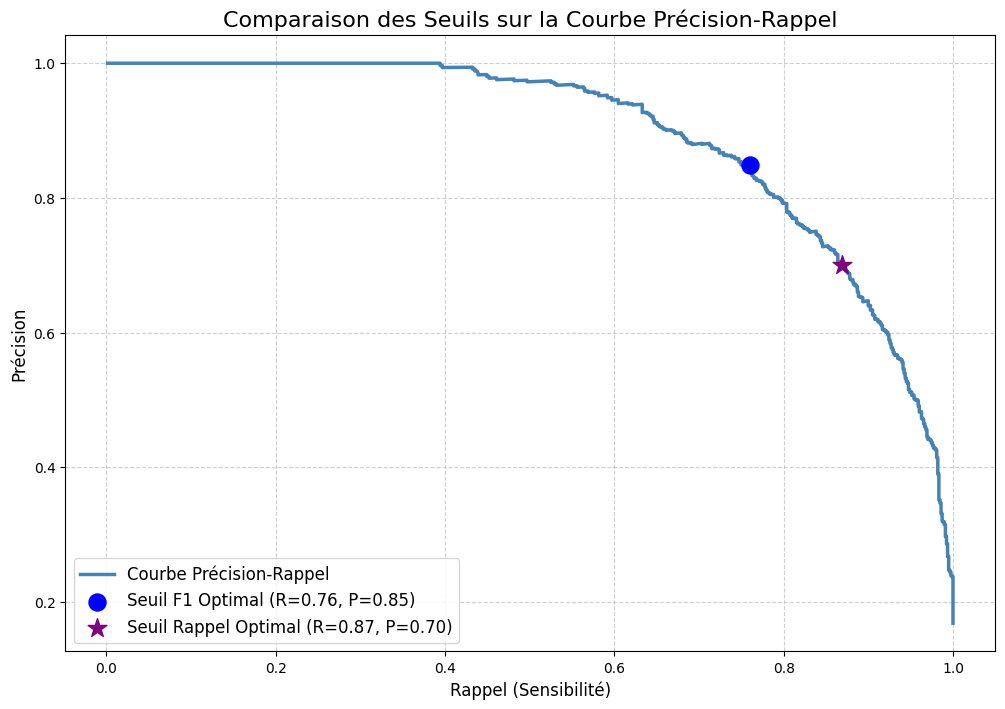

In [109]:
# --- Graphique 2 : Courbe Précision-Rappel avec les Deux Points Optimaux ---
# Objectif : Visualiser sur la "carte" des compromis où se situent nos deux stratégies.
plt.figure(figsize=(12, 8))
# La courbe
plt.plot(recalls[:-1], precisions[:-1], color='#4682B4', lw=2.5, label='Courbe Précision-Rappel')

# Le point optimisé pour le F1-Score
plt.scatter(recalls[best_idx_f1], precisions[best_idx_f1], marker='o', color='blue', s=150, zorder=5,
            label=f'Seuil F1 Optimal (R={recalls[best_idx_f1]:.2f}, P={precisions[best_idx_f1]:.2f})')

# Le point optimisé pour le Rappel
plt.scatter(recalls[best_idx_recall], precisions[best_idx_recall], marker='*', color='purple', s=200, zorder=5,
            label=f'Seuil Rappel Optimal (R={recalls[best_idx_recall]:.2f}, P={precisions[best_idx_recall]:.2f})')

plt.title('Comparaison des Seuils sur la Courbe Précision-Rappel', fontsize=16)
plt.xlabel('Rappel (Sensibilité)', fontsize=12)
plt.ylabel('Précision', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

#COMPARAISON VISUELLE DES MATRICES DE CONFUSION

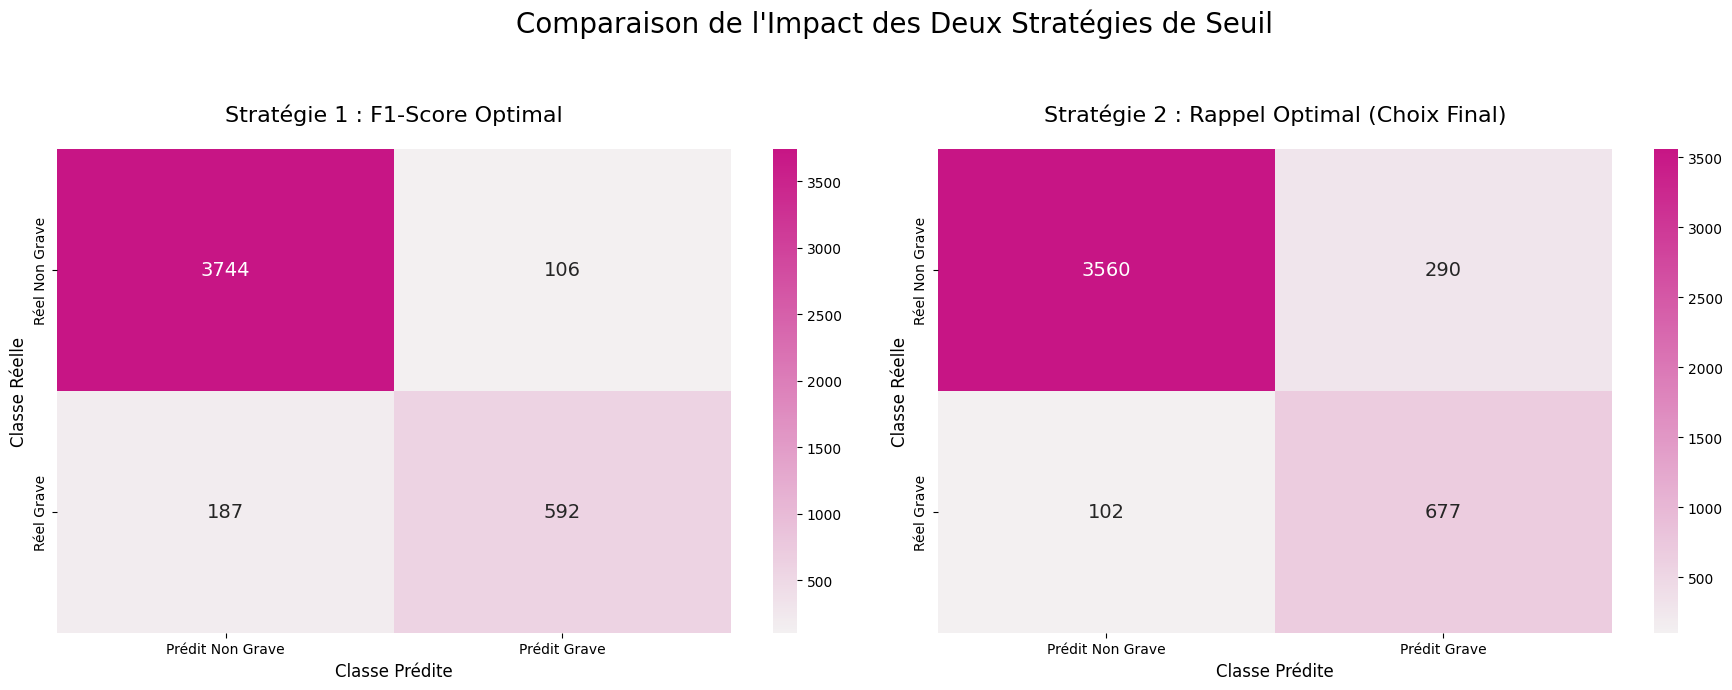

In [110]:
# ===================================================
# GRAPHIQUE : COMPARAISON VISUELLE DES MATRICES DE CONFUSION
# ===================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Définir une palette de couleurs féminine pour la heatmap
cmap_feminine = sns.light_palette("#C71585", as_cmap=True)

# Créer une figure avec deux sous-graphiques côte à côte
# figsize=(18, 7) donne assez d'espace pour que les deux graphiques soient bien lisibles
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Graphique de gauche : Matrice pour le seuil F1-Score ---
sns.heatmap(
    cm_f1,
    annot=True,          # Afficher les chiffres dans les cases
    fmt='d',             # Formater les chiffres comme des entiers
    cmap=cmap_feminine,  # Appliquer notre palette de couleurs
    ax=axes[0],          # Dessiner sur le premier sous-graphique (à gauche)
    xticklabels=['Prédit Non Grave', 'Prédit Grave'],
    yticklabels=['Réel Non Grave', 'Réel Grave'],
    annot_kws={"size": 14} # Augmenter la taille du texte pour la lisibilité
)
axes[0].set_title('Stratégie 1 : F1-Score Optimal', fontsize=16, pad=20)
axes[0].set_ylabel('Classe Réelle', fontsize=12)
axes[0].set_xlabel('Classe Prédite', fontsize=12)

# --- Graphique de droite : Matrice pour le seuil Rappel ---
sns.heatmap(
    cm_recall,
    annot=True,
    fmt='d',
    cmap=cmap_feminine,
    ax=axes[1],          # Dessiner sur le deuxième sous-graphique (à droite)
    xticklabels=['Prédit Non Grave', 'Prédit Grave'],
    yticklabels=['Réel Non Grave', 'Réel Grave'],
    annot_kws={"size": 14}
)
axes[1].set_title('Stratégie 2 : Rappel Optimal (Choix Final)', fontsize=16, pad=20)
axes[1].set_ylabel('Classe Réelle', fontsize=12)
axes[1].set_xlabel('Classe Prédite', fontsize=12)

# Titre général pour l'ensemble des deux graphiques
fig.suptitle('Comparaison de l\'Impact des Deux Stratégies de Seuil', fontsize=20)

# Ajuster la mise en page pour éviter que les titres se chevauchent
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Afficher les graphiques
plt.show()

#9 : Tâche 2 (Multiclasse) - Définition et entraînement du modèle
Pour la classification multiclasse, nous utilisons un modèle XGBClassifier seul, car il est nativement très efficace pour cette tâche. Nous devons mapper les étiquettes de classe à des entiers commençant par 0, puis entraîner le modèle.

In [89]:
# ===================================================
# 9. TÂCHE 2 (MULTICLASSE) : MODÈLE ET ENTRAÎNEMENT
# ===================================================
print("\n--- TÂCHE 2 : CLASSIFICATION MULTICLASSE (1-11) ---")

# Définition du modèle XGBoost pour le multiclasse
xgb_multi = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_multi)), # Nombre de classes unique
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

# Pipeline simple (préprocesseur + classifieur)
multi_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_multi)
])

# Mapper les labels de classe pour qu'ils commencent à 0
unique_classes = sorted(data['PLT'].unique())
class_map = {cls: i for i, cls in enumerate(unique_classes)}
inv_class_map = {i: cls for cls, i in class_map.items()}

y_train_multi_mapped = y_train_multi.map(class_map)

print("Entraînement du modèle multiclasse (XGBoost)...")
multi_pipeline.fit(X_train, y_train_multi_mapped)
print("Entraînement terminé.")


--- TÂCHE 2 : CLASSIFICATION MULTICLASSE (1-11) ---
Entraînement du modèle multiclasse (XGBoost)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:10:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entraînement terminé.


In [90]:
from IPython.display import display, HTML

html_code = """
### Architecture du Modèle Multiclasse : XGBoost

Pour la Tâche 2, nous utilisons un modèle très puissant : **XGBoost**. Il construit une série de "mini" modèles (des arbres de décision) les uns après les autres, où chaque nouveau modèle tente de corriger les erreurs des précédents.

<div style="font-family: Arial, sans-serif; text-align: center; border: 2px solid #DB7093; border-radius: 10px; padding: 20px; background-color: #FFF0F5;">
    <h4 style="color: #C71585;">Données d'Entrée (Avis + Molécula)</h4>
    <p style="font-size: 24px; margin: 0; color: #DB7093;">⬇</p>

    <div style="border: 1.5px solid #BA55D3; border-radius: 8px; padding: 15px; background-color: #F8F8FF;">
        <h4 style="margin: 0; color: #9370DB;">Pipeline de Pré-traitement</h4>
    </div>

    <p style="font-size: 24px; margin: 10px 0; color: #DB7093;">⬇</p>

    <div style="border: 2px solid #C71585; border-radius: 8px; padding: 15px; background-color: #FFE4E1;">
        <h4 style="margin: 0; color: #C71585;">Modèle XGBoost Multiclasse</h4>
        <div style="display: flex; justify-content: center; align-items: center; margin-top: 15px; font-size: 14px;">
            <div style="border: 1px dashed #888; padding: 8px; border-radius: 5px;">Arbre 1</div>
            <span style="font-size: 20px; margin: 0 10px; color: #DB7093;">➕</span>
            <div style="border: 1px dashed #888; padding: 8px; border-radius: 5px;">Arbre 2</div>
            <span style="font-size: 20px; margin: 0 10px; color: #DB7093;">➕</span>
            <div style="border: 1px dashed #888; padding: 8px; border-radius: 5px;">... N Arbres</div>
        </div>
    </div>

    <p style="font-size: 24px; margin: 10px 0; color: #DB7093;">⬇</p>

    <h4 style="color: #C71585;">Prédiction Finale (Classe de 1 à 11)</h4>
</div>
"""

display(HTML(html_code))

#10 : Tâche 2 (Multiclasse) - Prédiction et évaluation
Nous utilisons le modèle entraîné pour faire des prédictions sur l'ensemble de test. Les étiquettes prédites (qui sont des entiers de 0 à N) sont ensuite re-mappées vers leurs valeurs d'origine (1 à 11) pour pouvoir les évaluer et les interpréter correctement

In [91]:
# ===================================================
# 10. TÂCHE 2 (MULTICLASSE) : PRÉDICTION ET ÉVALUATION
# ===================================================
print("Prédiction sur l'ensemble de test...")

# Prédictions sur les données de test
y_pred_multi_mapped = multi_pipeline.predict(X_test)

# Re-mapper les prédictions vers les labels d'origine
y_pred_multi = pd.Series(y_pred_multi_mapped).map(inv_class_map)

# Afficher les résultats
print("\n--- Résultats Tâche 2 (XGBoost) ---")
print(classification_report(y_test_multi, y_pred_multi, zero_division=0))

Prédiction sur l'ensemble de test...

--- Résultats Tâche 2 (XGBoost) ---
              precision    recall  f1-score   support

           1       0.83      0.93      0.87      2253
           2       0.83      0.70      0.76       151
           3       0.54      0.31      0.40       194
           4       0.77      0.74      0.75       613
           5       0.64      0.55      0.60       166
           6       0.83      0.80      0.82       193
           7       0.00      0.00      0.00         2
           8       0.76      0.72      0.74       589
           9       1.00      0.75      0.86         4
          10       0.66      0.63      0.64       148
          11       0.64      0.51      0.57       316

    accuracy                           0.78      4629
   macro avg       0.68      0.60      0.64      4629
weighted avg       0.77      0.78      0.78      4629



#Après l'Étape 10 : Évaluation du Modèle Multiclasse
Pour le modèle multiclasse, les visualisations sont essentielles pour comprendre les erreurs en détail.
Graphique 5 : Matrice de Confusion en Carte de Chaleur (Heatmap)
Objectif : Identifier rapidement quelles classes sont souvent confondues entre elles. Par exemple, le modèle confond-il souvent la classe 3 avec la 8 ?

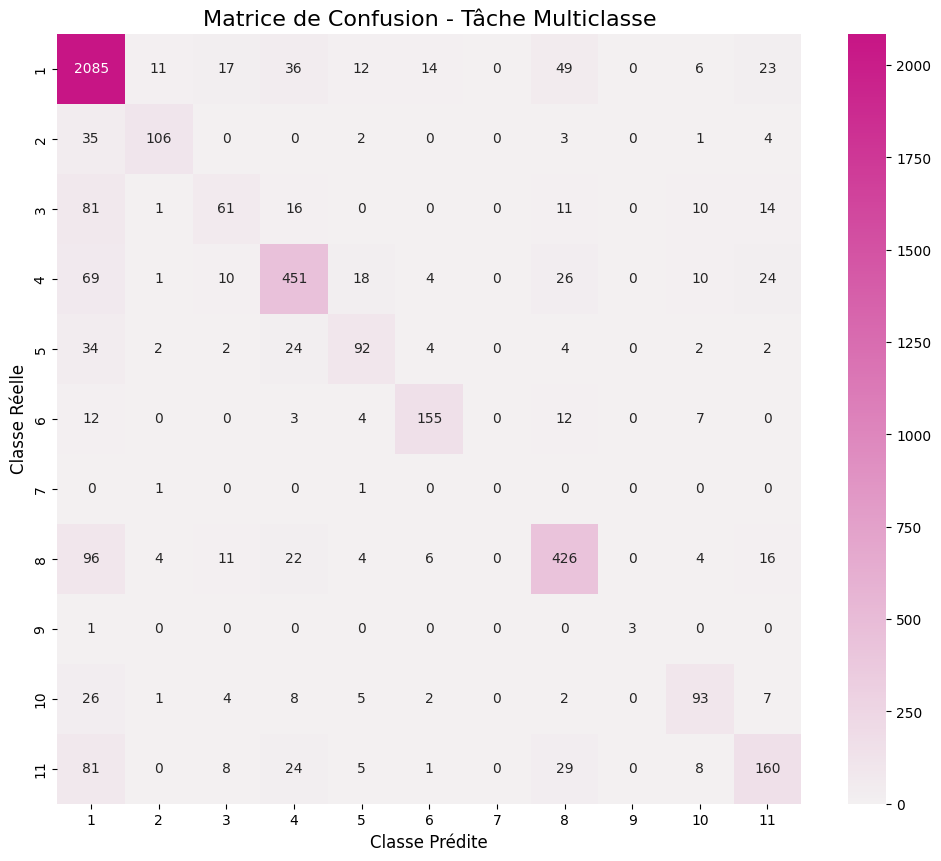

In [92]:
# ===================================================
# GRAPHIQUE 5 : MATRICE DE CONFUSION (MODÈLE MULTICLASSE)
# ===================================================
from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
class_labels = sorted(y_multi.unique())

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap=cmap_feminine,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matrice de Confusion - Tâche Multiclasse', fontsize=16)
plt.xlabel('Classe Prédite', fontsize=12)
plt.ylabel('Classe Réelle', fontsize=12)
plt.show()

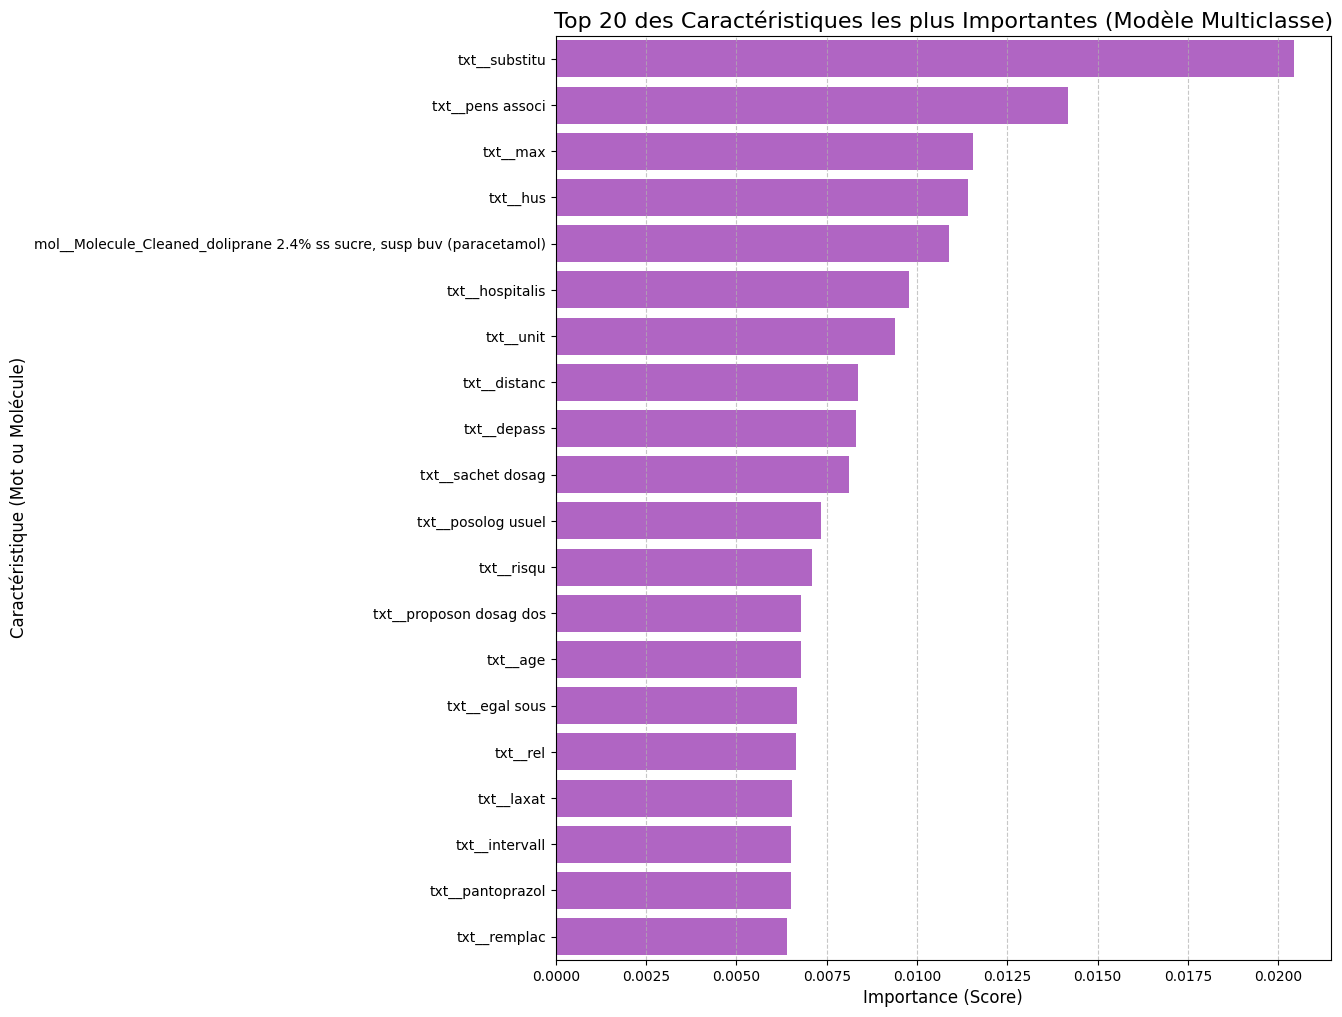

In [93]:
#### **Graphique 6 : Importance des Caractéristiques (Features)**

# ===================================================
# GRAPHIQUE 6 : IMPORTANCE DES CARACTÉRISTIQUES (XGBOOST)
# ===================================================
# Extraire le modèle XGBoost et le préprocesseur du pipeline
xgb_model = multi_pipeline.named_steps['classifier']
preprocessor_fitted = multi_pipeline.named_steps['preprocessor']

# Obtenir les noms de toutes les caractéristiques après le préprocesseur
# Utiliser get_feature_names_out() sur le preprocessor ajusté
feature_names = list(preprocessor_fitted.get_feature_names_out())

# Créer un DataFrame avec les importances
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Afficher les 20 caractéristiques les plus importantes
plt.figure(figsize=(10, 12))
sns.barplot(x='importance', y='feature', data=df_importance.head(20), color='#BA55D3')
plt.title('Top 20 des Caractéristiques les plus Importantes (Modèle Multiclasse)', fontsize=16)
plt.xlabel('Importance (Score)', fontsize=12)
plt.ylabel('Caractéristique (Mot ou Molécule)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#11 : Génération du fichier de soumission "données test"
rassemble les prédictions des deux tâches (Statut_Grave et Classe_Predite) dans un DataFrame et le sauvegarde dans un fichier CSV, comme requis pour la soumission du défi.

In [94]:
# ===================================================
# 11. GÉNÉRATION DU FICHIER DE SOUMISSION
# ===================================================

# Créer un DataFrame pour les prédictions finales
df_predictions_final = pd.DataFrame({
    'Statut_Grave': y_pred_bin_opt,
    'Classe_Predite': y_pred_multi
})

# Sauvegarder dans un fichier CSV
output_filename = 'predictions_test_set.csv'
df_predictions_final.to_csv(output_filename, index=False)

print(f"\nFichier '{output_filename}' généré avec succès.")
print(f"Il contient {len(df_predictions_final)} lignes.")

# Afficher un aperçu du fichier généré
print("\nAperçu du fichier de prédictions :")
print(df_predictions_final.head())


Fichier 'predictions_test_set.csv' généré avec succès.
Il contient 4629 lignes.

Aperçu du fichier de prédictions :
   Statut_Grave  Classe_Predite
0             0               1
1             0               1
2             0               6
3             1               1
4             1               1


#12 : Chargement du nouveau jeu de données de validation
 charge le fichier valid_set.csv dans un nouveau DataFrame. Il est important de spécifier le bon séparateur (;) et de vérifier que les données sont correctement chargées.

In [95]:
# ===================================================
# 1. CHARGEMENT DU JEU DE DONNÉES DE VALIDATION
# ===================================================

# Nom du fichier de validation
validation_filename = 'valid_set.csv'

try:
    # Chargement des données dans un nouveau DataFrame
    df_valid = pd.read_csv(validation_filename, sep=';')
    print(f"Fichier '{validation_filename}' chargé avec succès.")
    print(f"Il contient {len(df_valid)} lignes.")

    # Afficher un aperçu pour vérifier le chargement
    print("\nAperçu des données de validation :")
    print(df_valid.head())

except FileNotFoundError:
    print(f"Erreur : Le fichier '{validation_filename}' n'a pas été trouvé. Assurez-vous qu'il est dans le bon répertoire.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier : {e}")

Fichier 'valid_set.csv' chargé avec succès.
Il contient 4148 lignes.

Aperçu des données de validation :
                                Libellé.Prescription  \
0  perf NEFOPAM 60 mg (Acupan) + 1.25 DROPERIDOL ...   
1                                   LAMALINE, GÉLULE   
2                                   XYZALL 5 MG, CPR   
3  AMOXICILLINE + A.CLAVULANIQUE 1g x4/j (Augmentin)   
4  FELODIPINE LP 5 MG SANDOZ, CPR À LIBÉRATION PR...   

                                 Avis.Pharmaceutique  
0  ASSOCIATION CONTRE INDIQUEE : SEROPLEX 20 MG C...  
1  Propose arrêt pendant hospitalisation ou DOLIP...  
2  Non référencé aux HUS, propose CETIRIZINE 10MG...  
3  Il est recommandé de réduire la posologie en a...  
4  Non référencé aux HUS, Substitué par amlodipin...  


#13 : Application du nettoyage et du prétraitement
Nous appliquons exactement la même fonction de nettoyage (clean_text) et créons les mêmes colonnes (Avis_Cleaned, Molecule_Cleaned) que pour le jeu d'entraînement. Cela garantit que les données sont dans le format attendu par les modèles.

In [96]:
# ===================================================
# 2. APPLICATION DU MÊME PRÉTRAITEMENT QU'À L'ENTRAÎNEMENT
# ===================================================

# Assurez-vous que la fonction clean_text est définie et disponible
# (elle l'est si vous exécutez cette cellule dans le même notebook que l'entraînement)

print("Nettoyage et préparation des données de validation...")

# Handle potential NaN values in 'Avis.Pharmaceutique' before applying string operations
df_valid['Avis.Pharmaceutique'] = df_valid['Avis.Pharmaceutique'].fillna('')

# Appliquer le nettoyage de texte sur la colonne 'Avis.Pharmaceutique'
df_valid['Avis_Cleaned'] = df_valid['Avis.Pharmaceutique'].apply(clean_text)

# Nettoyer la colonne 'Libellé.Prescription' pour créer la feature 'Molecule_Cleaned'
df_valid['Molecule_Cleaned'] = df_valid['Libellé.Prescription'].astype(str).str.lower().str.strip()

# --- NOUVEAUTÉ : Ajouter les caractéristiques basées sur des mots-clés pour les données de validation ---
# On applique ces règles sur le texte original, avant nettoyage complet
avis_brut_valid = df_valid['Avis.Pharmaceutique'].str.lower()
df_valid['contient_ci'] = avis_brut_valid.str.contains('contre-indiqu|contre indication|CI', regex=True).astype(int)
df_valid['contient_surdosage'] = avis_brut_valid.str.contains('surdosage|diminuer la dose|réduire la posologie|dose trop|posologie élevée', regex=True).astype(int)
df_valid['contient_interaction'] = avis_brut_valid.str.contains('interaction|association déconseillée', regex=True).astype(int)
print("Nouvelles caractéristiques (mots-clés) créées pour les données de validation.")


# Définir le DataFrame de features pour la prédiction
# MISE À JOUR : Inclure les nouvelles colonnes de mots-clés
X_valid = df_valid[['Avis_Cleaned', 'Molecule_Cleaned', 'contient_ci', 'contient_surdosage', 'contient_interaction']]


print("Prétraitement terminé.")
print("\nAperçu des données après nettoyage et feature engineering :")
X_valid.head()

Nettoyage et préparation des données de validation...
Nouvelles caractéristiques (mots-clés) créées pour les données de validation.
Prétraitement terminé.

Aperçu des données après nettoyage et feature engineering :


,Avis_Cleaned,Molecule_Cleaned,contient_ci,contient_surdosage,contient_interaction
0,associ contr indique seroplex dosag droleptan ...,perf nefopam 60 mg (acupan) + 1.25 droperidol ...,0,0,0
1,propos arret pend hospitalis dolipran dosag ge...,"lamaline, gélule",0,0,0
2,non referent aux hus propos cetirizin dosag fo...,"xyzall 5 mg, cpr",0,0,0
3,est recommand reduir posolog acid clavulan pre...,amoxicilline + a.clavulanique 1g x4/j (augmentin),0,1,0
4,non referent aux hus substitu par amlodipin do...,"felodipine lp 5 mg sandoz, cpr à libération pr...",0,0,0


#14: Génération des prédictions binaires et multiclasses
nous utilisons les pipelines binary_pipeline et multi_pipeline (qui ont été entraînés précédemment) pour prédire les résultats sur les nouvelles données X_valid.
Pour la tâche binaire, on utilise predict_proba() pour appliquer notre seuil optimisé (best_threshold).
Pour la tâche multiclasse, on utilise predict() et on re-mappe les résultats numériques vers les classes originales avec inv_class_map.

In [99]:
# ===================================================
# 3. GÉNÉRATION DES PRÉDICTIONS AVEC LES MODÈLES ENTRAÎNÉS
# ===================================================

# Assurez-vous que les objets 'binary_pipeline', 'multi_pipeline', 'best_threshold_recall',
# et 'inv_class_map' existent en mémoire.

print("--- Tâche 1 : Prédiction binaire (Grave/Non Grave) ---")
# Obtenir les probabilités de la classe "grave" (classe 1) sur les données de validation
y_probas_valid = binary_pipeline.predict_proba(X_valid)[:, 1]

# Appliquer le seuil de décision optimal trouvé pendant l'entraînement (le seuil optimisé pour le rappel)
# Utilise best_threshold_recall défini dans la cellule MD95jz-Orbjp
if 'best_threshold_recall' in locals():
    y_pred_bin_valid = (y_probas_valid >= best_threshold_recall).astype(int)
    print("Prédictions binaires générées.")
else:
    print("Erreur: La variable 'best_threshold_recall' n'est pas définie. Assurez-vous d'avoir exécuté la cellule d'optimisation du seuil (MD95jz-Orbjp).")
    # Créer un placeholder ou gérer l'absence de prédictions si le seuil n'est pas défini
    y_pred_bin_valid = pd.Series(np.nan, index=X_valid.index) # Utiliser NaN ou une autre indication


print("\n--- Tâche 2 : Prédiction multiclasse (Classes 1-11) ---")
# Prédire les classes mappées (de 0 à N) sur les données de validation
y_pred_multi_mapped_valid = multi_pipeline.predict(X_valid)

# Revenir aux labels de classe d'origine (1 à 11) en utilisant le mappage inverse
# Assurez-vous que inv_class_map est défini (il est défini dans la cellule rT-1AyMSruqp)
if 'inv_class_map' in locals():
    y_pred_multi_valid = pd.Series(y_pred_multi_mapped_valid).map(inv_class_map)
    print("Prédictions multiclasses générées.")
else:
    print("Erreur: La variable 'inv_class_map' n'est pas définie. Assurez-vous d'avoir exécuté la cellule d'entraînement multiclasse (rT-1AyMSruqp).")
    y_pred_multi_valid = pd.Series(np.nan, index=X_valid.index) # Utiliser NaN ou une autre indication

--- Tâche 1 : Prédiction binaire (Grave/Non Grave) ---
Prédictions binaires générées.

--- Tâche 2 : Prédiction multiclasse (Classes 1-11) ---
Prédictions multiclasses générées.


#15: Création du fichier de soumission final
nous assemblons les deux séries de prédictions dans un DataFrame final et le sauvegardons dans un fichier CSV, conformément aux exigences du défi.

In [100]:
# ===================================================
# 4. CRÉATION DU FICHIER DE SOUMISSION POUR LE JEU DE VALIDATION
# ===================================================

# Créer un DataFrame contenant les deux colonnes de prédictions
df_submission = pd.DataFrame({
    'Statut_Grave': y_pred_bin_valid,
    'Classe_Predite': y_pred_multi_valid
})

# Nom du fichier de sortie
submission_filename = 'predictions_valid_set.csv'

# Sauvegarder le DataFrame au format CSV, sans l'index
df_submission.to_csv(submission_filename, index=False)

print(f"\nLe fichier de soumission '{submission_filename}' a été généré avec succès.")
print(f"Il contient {len(df_submission)} prédictions.")

# Afficher un aperçu du fichier final
print("\nAperçu du fichier de soumission :")
print(df_submission.head())


Le fichier de soumission 'predictions_valid_set.csv' a été généré avec succès.
Il contient 4148 prédictions.

Aperçu du fichier de soumission :
   Statut_Grave  Classe_Predite
0             0               6
1             0               2
2             0               1
3             1               4
4             0               1


#Analyse Qualitative

In [101]:
# ===================================================
# 5. VÉRIFICATION QUALITATIVE DES PRÉDICTIONS
# ===================================================

# Assurez-vous que df_submission a bien été créé dans la cellule précédente

# Concaténer les avis originaux avec leurs prédictions
# Crée un nouveau DataFrame en combinant la colonne originale 'Avis.Pharmaceutique'
# du DataFrame de validation (df_valid) avec les colonnes de prédictions ('Statut_Grave', 'Classe_Predite')
# du DataFrame de soumission (df_submission). Cela permet de visualiser facilement
# les avis originaux et les prédictions correspondantes côte à côte.
df_verif = pd.concat([
    df_valid[['Avis.Pharmaceutique']],
    df_submission[['Statut_Grave', 'Classe_Predite']]
], axis=1) # axis=1 indique de concaténer le long des colonnes

# Afficher quelques exemples, en particulier ceux prédits comme "graves" (Statut_Grave = 1)
# Filtre le DataFrame df_verif pour n'afficher que les lignes où la prédiction 'Statut_Grave' est 1.
# .head(10) affiche les 10 premières de ces lignes.
print("--- Exemples de prédictions sur les cas détectés comme 'Grave' ---")
print(df_verif[df_verif['Statut_Grave'] == 1].head(10))

# Afficher quelques exemples, en particulier ceux prédits comme "non graves" (Statut_Grave = 0)
# Filtre le DataFrame df_verif pour n'afficher que les lignes où la prédiction 'Statut_Grave' est 0.
# .head(10) affiche les 10 premières de ces lignes.
print("\n--- Exemples de prédictions sur les cas détectés comme 'Non Grave' ---")
print(df_verif[df_verif['Statut_Grave'] == 0].head(10))

--- Exemples de prédictions sur les cas détectés comme 'Grave' ---
                                  Avis.Pharmaceutique  Statut_Grave  \
3   Il est recommandé de réduire la posologie en a...             1   
10  Refusé pour le motif suivant : au vue de la DF...             1   
15      initiation xarelto et arret PSE héparine\n \n             1   
16  Le médicament sera dispensé en même temps que ...             1   
18  Refusé pour le motif suivant : au vue de l'âge...             1   
30  Refusé pour le motif suivant : 2 prescriptions...             1   
37           Réévaluer date de début de traitement G.             1   
45  Propososn 3g max par jour chez la patiente de ...             1   
48  proposons de diminuer la dose à 20mg par jour ...             1   
49  K= 4.55 le 15/03: envisager l'arrêt de la supp...             1   

    Classe_Predite  
3                4  
10               4  
15               5  
16               5  
18               4  
30               4  
37  

#**Limites du modèle **: L'analyse qualitative a révélé le point faible le plus important : le modèle peut manquer des cas graves évidents (Faux Négatifs), comme l'a montré l'exemple de l'"ASSOCIATION CONTRE INDIQUEE". C'est un risque inhérent à tout modèle de classification automatique.

In [102]:
# ===================================================
# 6. VÉRIFICATION DE LA DISTRIBUTION DES PRÉDICTIONS
# ===================================================

# Assurez-vous que df_submission a bien été créé dans la cellule précédente

# Proportion des classes dans les prédictions binaires sur le jeu de validation
print("--- Distribution des prédictions binaires sur 'valid_set.csv' ---")
# Calcule la fréquence de chaque valeur dans la colonne 'Statut_Grave' (0 ou 1)
# normalize=True affiche les proportions (pourcentage) au lieu des comptes bruts
print(df_submission['Statut_Grave'].value_counts(normalize=True))

# Rappel : Proportion des classes dans votre jeu de test interne (pour comparaison)
# Cela permet de comparer la distribution des prédictions sur le jeu de validation
# avec la distribution réelle des classes sur le jeu de test interne.
print("\n--- Distribution réelle des classes sur votre jeu de test interne (pour rappel) ---")
# Calcule la proportion réelle de cas graves et non graves dans l'ensemble de test original
print(y_test_bin.value_counts(normalize=True))

--- Distribution des prédictions binaires sur 'valid_set.csv' ---
Statut_Grave
0    0.787608
1    0.212392
Name: proportion, dtype: float64

--- Distribution réelle des classes sur votre jeu de test interne (pour rappel) ---
PLT
0    0.831713
1    0.168287
Name: proportion, dtype: float64


Le fait que nous prédisions 21.2% de cas graves au lieu des 16.8% réels est la manifestation directe et attendue de cette stratégie. nous avons augmenté le nombre de Faux Positifs pour diminuer le nombre de Faux Négatifs, ce qui a mécaniquement augmenté la proportion totale de prédictions "Grave".

# GRAPHIQUE : COMPARAISON DES DISTRIBUTIONS DES CLASSES

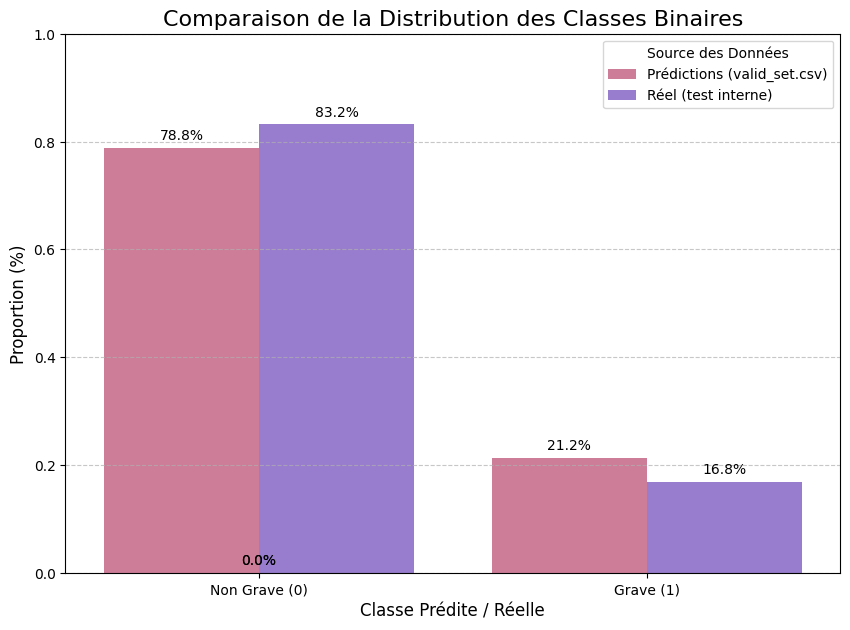

In [111]:
# ===================================================
# GRAPHIQUE : COMPARAISON DES DISTRIBUTIONS DES CLASSES
# ===================================================

# 1. Calculer les proportions pour les deux ensembles de données
prop_validation = df_submission['Statut_Grave'].value_counts(normalize=True)
prop_test_interne = y_test_bin.value_counts(normalize=True)

# 2. Créer un DataFrame pour faciliter la visualisation avec Seaborn
df_plot = pd.DataFrame({
    'Proportion': pd.concat([prop_validation, prop_test_interne]),
    'Ensemble': ['Prédictions (valid_set.csv)'] * len(prop_validation) + ['Réel (test interne)'] * len(prop_test_interne),
    'Classe': ['Non Grave (0)', 'Grave (1)'] * 2 # S'assurer que les labels correspondent
})

# 3. Créer le graphique à barres
plt.figure(figsize=(10, 7))
barplot = sns.barplot(
    x='Classe',
    y='Proportion',
    hue='Ensemble',
    data=df_plot,
    palette=['#DB7093', '#9370DB'] # Choisir deux couleurs de votre palette
)

plt.title('Comparaison de la Distribution des Classes Binaires', fontsize=16)
plt.ylabel('Proportion (%)', fontsize=12)
plt.xlabel('Classe Prédite / Réelle', fontsize=12)
plt.ylim(0, 1) # S'assurer que l'axe Y va de 0 à 100%

# Ajouter les pourcentages au-dessus des barres pour plus de clarté
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.1%}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.legend(title='Source des Données')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()